# Demo: Red social Karate Club
En esta versión voy a incluir GNN de más de una capa oculta

In [1]:
# Cargamos las librerías necesarias y el grafo de ejemplo
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
G = nx.karate_club_graph()

## 1. Introducción
### 1.1 Inspección básica

In [2]:
print(type(G))
print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")

<class 'networkx.classes.graph.Graph'>
Número de nodos: 34
Número de aristas: 78


In [3]:
list(G.nodes())[:10]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [4]:
list(G.edges())[:10]

[(0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 10),
 (0, 11)]

In [5]:
print(G.nodes[0])
print(G.nodes[33])

{'club': 'Mr. Hi'}
{'club': 'Officer'}


### 1.2. Visualización General

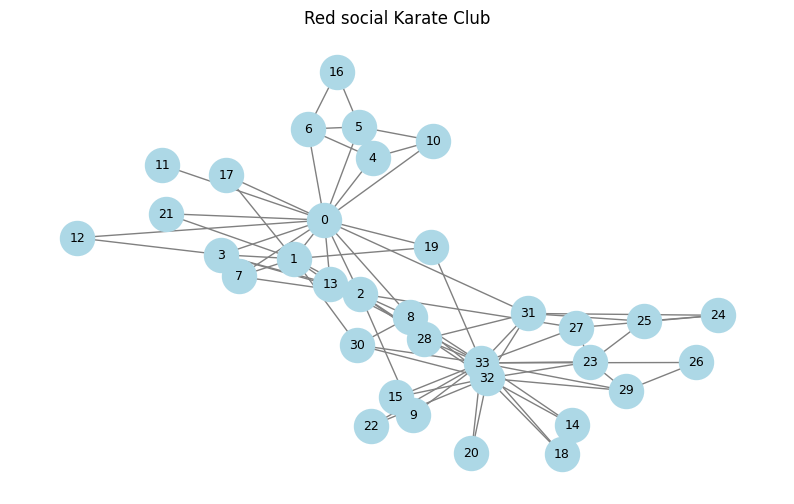

In [6]:
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color="lightblue",
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Red social Karate Club")
plt.axis("off")
plt.show()

### 1.3. Comunidades del club

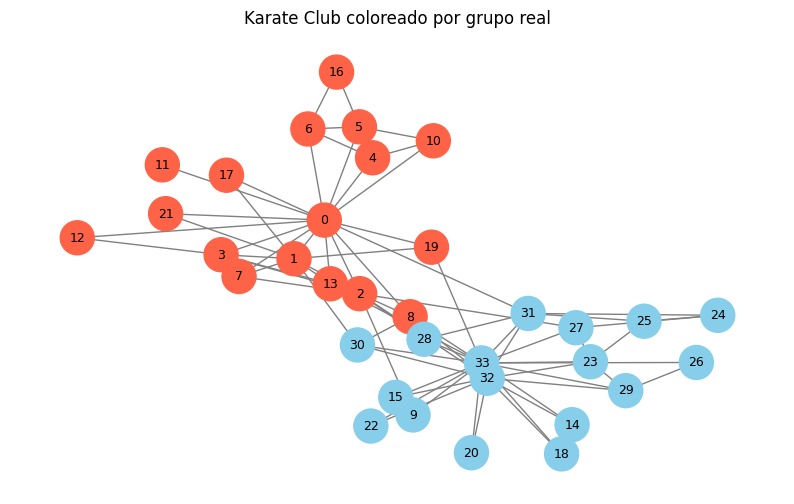

In [7]:
# coloreamos por comunidad
club_labels = nx.get_node_attributes(G, "club")
node_colors = [
    "tomato" if club_labels[n] == "Mr. Hi" else "skyblue"
    for n in G.nodes()
]
plt.figure(figsize=(10, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Karate Club coloreado por grupo real")
plt.axis("off")
plt.show()

## 2. Algoritmo "clásico" de división en comunidades
### 2.1 Sin especificar número de comunidades

Número de comunidades detectadas: 3
Comunidad 0: [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Comunidad 1: [1, 2, 3, 7, 9, 12, 13, 17, 21]
Comunidad 2: [0, 4, 5, 6, 10, 11, 16, 19]


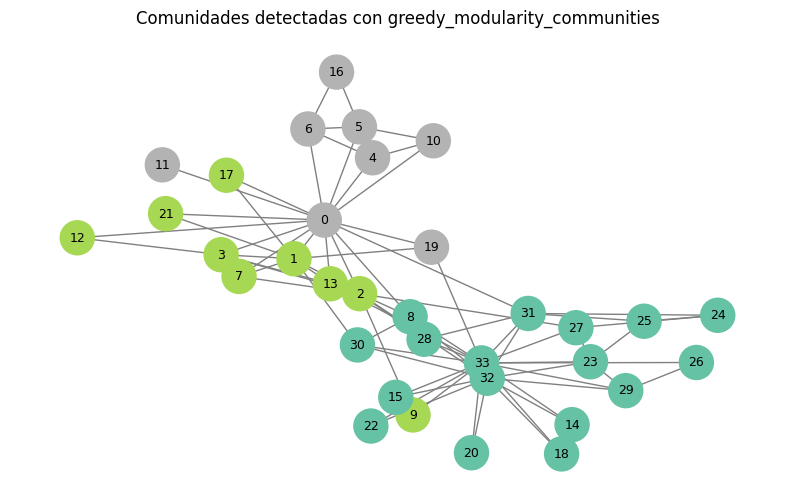

In [8]:
from networkx.algorithms.community import greedy_modularity_communities

# Detectar comunidades
communities = greedy_modularity_communities(G)

print(f"Número de comunidades detectadas: {len(communities)}")
for i, c in enumerate(communities):
    print(f"Comunidad {i}: {sorted(c)}")

# Crear mapa nodo -> comunidad
node_to_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_to_community[node] = i

# Colores
colors = [node_to_community[n] for n in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=colors,
    cmap=plt.cm.Set2,
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Comunidades detectadas con greedy_modularity_communities")
plt.axis("off")
plt.show()

### 2.2 Forzamos a que identifique DOS comunidades

Número de comunidades detectadas: 2
Comunidad 0: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 19, 21]
Comunidad 1: [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


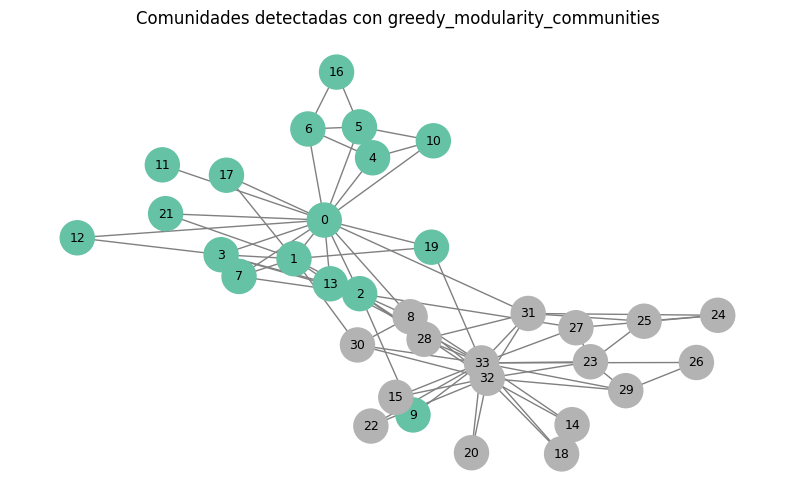

In [9]:
communities = greedy_modularity_communities(G, cutoff=2, best_n=2)
print(f"Número de comunidades detectadas: {len(communities)}")
for i, c in enumerate(communities):
    print(f"Comunidad {i}: {sorted(c)}")

# Crear mapa nodo -> comunidad
node_to_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_to_community[node] = i

# Colores
colors = [node_to_community[n] for n in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=colors,
    cmap=plt.cm.Set2,
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Comunidades detectadas con greedy_modularity_communities")
plt.axis("off")
plt.show()

## 3. Medidas simples de un nodo (centralidad)
(Nodos más conectados y más centrales)
### 3.1 Centralidad de Grado

In [10]:
degrees = dict(G.degree())
degrees

{0: 16,
 1: 9,
 2: 10,
 3: 6,
 4: 3,
 5: 4,
 6: 4,
 7: 4,
 8: 5,
 9: 2,
 10: 3,
 11: 1,
 12: 2,
 13: 5,
 14: 2,
 15: 2,
 16: 2,
 17: 2,
 18: 2,
 19: 3,
 20: 2,
 21: 2,
 22: 2,
 23: 5,
 24: 3,
 25: 3,
 26: 2,
 27: 4,
 28: 3,
 29: 4,
 30: 4,
 31: 6,
 32: 12,
 33: 17}

In [11]:
df_nodes = pd.DataFrame({
    "node": list(G.nodes()),
    "club": [club_labels[n] for n in G.nodes()],
    "degree": [degrees[n] for n in G.nodes()]
})

df_nodes.sort_values("degree", ascending=False).head(10)

,node,club,degree
33,33,Officer,17
0,0,Mr. Hi,16
32,32,Officer,12
2,2,Mr. Hi,10
1,1,Mr. Hi,9
3,3,Mr. Hi,6
31,31,Officer,6
23,23,Officer,5
8,8,Mr. Hi,5
13,13,Mr. Hi,5


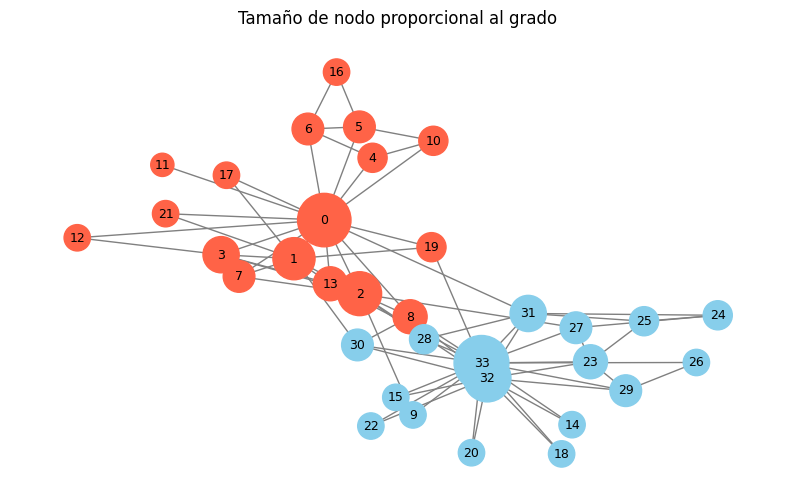

In [12]:
# Visualizar tamaño según grado
node_sizes = [200 + degrees[n] * 80 for n in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    node_size=node_sizes,
    font_size=9
)
plt.title("Tamaño de nodo proporcional al grado")
plt.axis("off")
plt.show()

### 3.2 Centralidad de Intermediación

In [13]:
# Intermediación
betweenness = nx.betweenness_centrality(G)

df_nodes["betweenness"] = df_nodes["node"].map(betweenness)
df_nodes.sort_values("betweenness", ascending=False).head(10)

,node,club,degree,betweenness
0,0,Mr. Hi,16,0.437635
33,33,Officer,17,0.304075
32,32,Officer,12,0.145247
2,2,Mr. Hi,10,0.143657
31,31,Officer,6,0.138276
8,8,Mr. Hi,5,0.055927
1,1,Mr. Hi,9,0.053937
13,13,Mr. Hi,5,0.045863
19,19,Mr. Hi,3,0.032475
5,5,Mr. Hi,4,0.029987


### 3.3 Centralidad de Cercanía

In [14]:
# Cercania
closeness = nx.closeness_centrality(G)

df_nodes["closeness"] = df_nodes["node"].map(closeness)
df_nodes.sort_values("closeness", ascending=False).head(10)

,node,club,degree,betweenness,closeness
0,0,Mr. Hi,16,0.437635,0.568966
2,2,Mr. Hi,10,0.143657,0.559322
33,33,Officer,17,0.304075,0.550000
31,31,Officer,6,0.138276,0.540984
13,13,Mr. Hi,5,0.045863,0.515625
8,8,Mr. Hi,5,0.055927,0.515625
32,32,Officer,12,0.145247,0.515625
19,19,Mr. Hi,3,0.032475,0.500000
1,1,Mr. Hi,9,0.053937,0.485294
3,3,Mr. Hi,6,0.011909,0.464789


### 3.4 Usamos variables para clasificar nodos

In [15]:
# Utilizando las 3 variables, hacemos clusterización de los nodos con KMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Usamos las tres medidas de centralidad; se escalan porque tienen rangos distintos.
centrality_features = ["degree", "betweenness", "closeness"]
X_centrality = df_nodes[centrality_features]
X_centrality_scaled = StandardScaler().fit_transform(X_centrality)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
df_nodes["centrality_cluster"] = kmeans.fit_predict(X_centrality_scaled)

df_nodes[["node", "club", *centrality_features, "centrality_cluster"]].sort_values("centrality_cluster")

,node,club,degree,betweenness,closeness,centrality_cluster
3,3,Mr. Hi,6,0.011909,0.464789,0
6,6,Mr. Hi,4,0.029987,0.383721,0
5,5,Mr. Hi,4,0.029987,0.383721,0
4,4,Mr. Hi,3,0.000631,0.379310,0
7,7,Mr. Hi,4,0.000000,0.440000,0
10,10,Mr. Hi,3,0.000631,0.379310,0
9,9,Officer,2,0.000848,0.434211,0
8,8,Mr. Hi,5,0.055927,0.515625,0
12,12,Mr. Hi,2,0.000000,0.370787,0
13,13,Mr. Hi,5,0.045863,0.515625,0


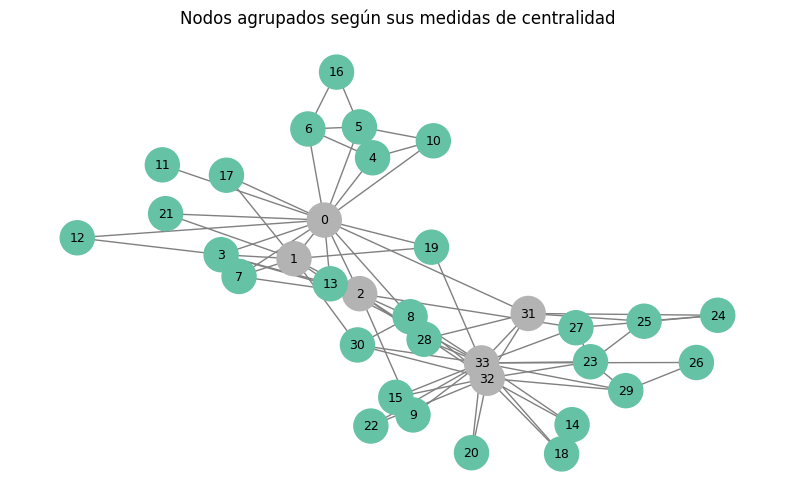

In [ ]:
# Visualizar los grupos obtenidos con KMeans a partir de las centralidades.
centrality_colors = [
    df_nodes.loc[df_nodes["node"] == node, "centrality_cluster"].iloc[0]
    for node in G.nodes()
]

plt.figure(figsize=(10, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=centrality_colors,
    cmap=plt.cm.Set2,
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Nodos agrupados según sus medidas de centralidad")
plt.axis("off")
plt.show()

# agrupa nodos muy relacionados con mucha centralidad. son dos comunidades nodos muy conectados con no muy conectados
# y no siempre funciona. por homofilia podría funcionar. nodos similares en grado tienden a juntarse.

## 4. Vecindario de un nodo

In [ ]:
# Escogemos un nodo "interesante" y mostramos sus vecinos
# en vez de centrarnos en la centralidad nos enfocamos en el vecindario tomando como referencia el nodo 0
node = 0
neighbors = list(G.neighbors(node))
print(f"Vecinos de {node}: {neighbors}")
print(f"Número de vecinos de {node}: {len(neighbors)}")

Vecinos de 0: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
Número de vecinos de 0: 16


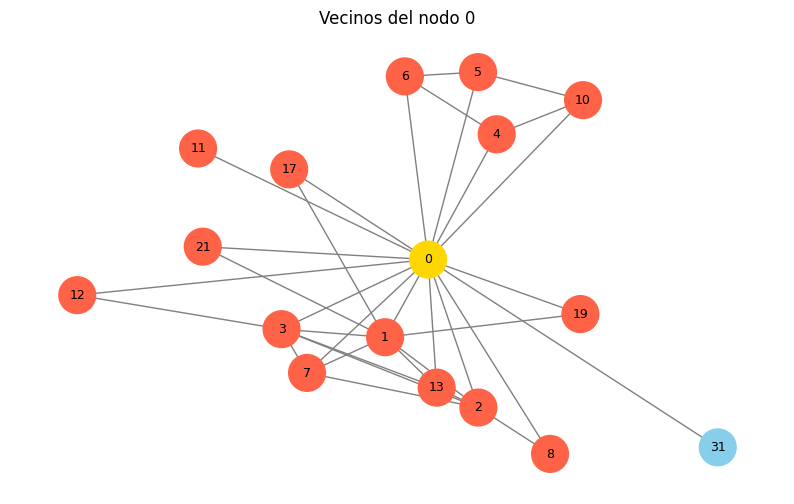

In [18]:
# Dibujamos solo el nodo y sus vecinos.
sub_nodes = [node] + neighbors
H = G.subgraph(sub_nodes)

pos_H = nx.spring_layout(H, seed=42)

colors_H = [
    "gold" if n == node else ("tomato" if club_labels[n] == "Mr. Hi" else "skyblue")
    for n in H.nodes()
]

plt.figure(figsize=(10, 6))
nx.draw_networkx(
    H,
    pos=pos,
    with_labels=True,
    node_color=colors_H,
    edge_color="gray",
    node_size=700,
    font_size=9
)
plt.title(f"Vecinos del nodo {node}")
plt.axis("off")
plt.show()

### 4.1 Una regla simple basada en vecinos

In [ ]:
# etiquetado de nodos basado en vecinos. es decir ponemos la etiqueta másmayoritaria de los vecinos

df_nodes["neighbors_mrhi"] = [
    sum(1 for nb in G.neighbors(n) if club_labels[nb] == "Mr. Hi")
    for n in G.nodes()
]

df_nodes["neighbors_officer"] = [
    sum(1 for nb in G.neighbors(n) if club_labels[nb] == "Officer")
    for n in G.nodes()
]

df_nodes.head(10)

,node,club,degree,betweenness,closeness,neighbors_mrhi,neighbors_officer
0,0,Mr. Hi,16,0.437635,0.568966,15,1
1,1,Mr. Hi,9,0.053937,0.485294,8,1
2,2,Mr. Hi,10,0.143657,0.559322,6,4
3,3,Mr. Hi,6,0.011909,0.464789,6,0
4,4,Mr. Hi,3,0.000631,0.379310,3,0
5,5,Mr. Hi,4,0.029987,0.383721,4,0
6,6,Mr. Hi,4,0.029987,0.383721,4,0
7,7,Mr. Hi,4,0.000000,0.440000,4,0
8,8,Mr. Hi,5,0.055927,0.515625,2,3
9,9,Officer,2,0.000848,0.434211,1,1


* si un nodo tiene la mayoría de vecinos en un grupo, eso ya da una pista
* aquí aparece la idea de agregar información local

No es GNN, pero se entiende la lógica de "mirar vecinos"

Ahora vemos cómo esto nos puede servir para clasificar:

la información de los vecinos aportan información sobre el nodo

In [19]:
# Predicción por mayoría de vecinos, enfoque totalmente ingenuo
def predict_by_neighbor_majority(node):
    neighbors = list(G.neighbors(node))
    if not neighbors:
        return None
    
    mrhi = sum(1 for nb in neighbors if club_labels[nb] == "Mr. Hi")
    officer = sum(1 for nb in neighbors if club_labels[nb] == "Officer")
    
    return "Mr. Hi" if mrhi >= officer else "Officer"

df_nodes["pred_majority_neighbors"] = df_nodes["node"].apply(predict_by_neighbor_majority)
df_nodes["correct"] = df_nodes["pred_majority_neighbors"] == df_nodes["club"]

df_nodes[["node", "club", "pred_majority_neighbors", "correct"]].head(15)
print("Accuracy:", df_nodes["correct"].mean())

Accuracy: 0.9117647058823529


una GNN hace algo parecido, pero de forma aprendida, más flexible y con varias capas

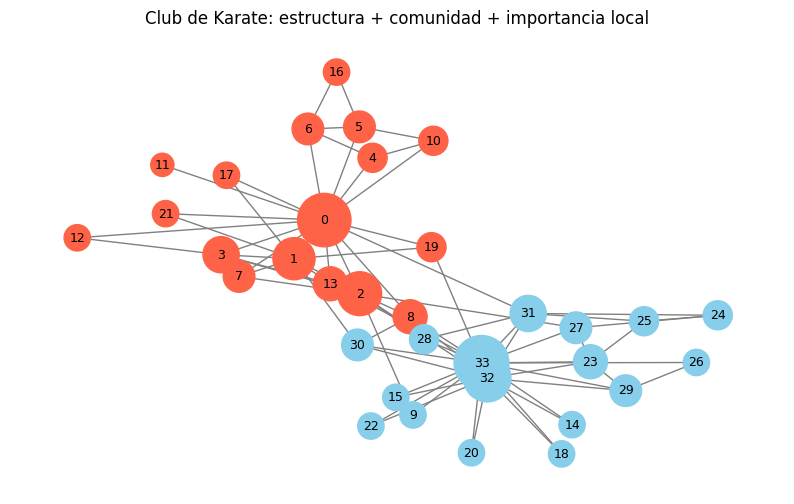

In [ ]:
plt.figure(figsize=(10, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    node_size=[200 + 80 * degrees[n] for n in G.nodes()],
    font_size=9
)
plt.title("Club de Karate: estructura + comunidad + importancia local")
plt.axis("off")
plt.show()


* la estructura ya nos habla de grupos
* algunos nodos ocupan posiciones más relevantes
* el vecindario aporta información útil
* esto motiva el aprendizaje automático basado en grafos

## 5. _Embeddings_
### 5.1 Generando los _embeddings_   
convierte grafos o nodos en un vector relativamente pequeño. Se usan redes neuronales para crear vectores de bajas dimensiones   

inspiración Word2Vec del procesamiento de lenguaje natural. transformar los grafos a 'frases'. asumiendo que cada nodo es una palabra   
Creando recorridos al azar. 
el deepWalk es parecido al Word2Vec  


In [21]:
%pip install -q --upgrade gensim scikit-learn

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Definimos funciones para generar recorridos

In [22]:
import random
import numpy as np

from gensim.models import Word2Vec


def random_walk(G, start_node, walk_length, rng):
    """
    Genera un recorrido aleatorio uniforme desde start_node.
    """
    walk = [start_node]

    while len(walk) < walk_length:
        current_node = walk[-1]
        neighbors = list(G.neighbors(current_node))

        # Si el nodo no tiene vecinos, termina el paseo
        if not neighbors:
            break

        next_node = rng.choice(neighbors)
        walk.append(next_node)

    return walk


def generate_deepwalk_walks(
    G,
    num_walks=100,
    walk_length=20,
    seed=42
):
    """
    Genera num_walks recorridos desde cada nodo del grafo.
    """
    rng = random.Random(seed)
    nodes = list(G.nodes())
    walks = []

    for _ in range(num_walks):
        # Cambiamos el orden de los nodos en cada ronda
        shuffled_nodes = nodes.copy()
        rng.shuffle(shuffled_nodes)

        for node in shuffled_nodes:
            walk = random_walk(
                G,
                start_node=node,
                walk_length=walk_length,
                rng=rng
            )

            # Word2Vec espera tokens; usamos identificadores como cadenas
            walks.append([str(node) for node in walk])

    return walks

Generar los recorridos

In [23]:
walks = generate_deepwalk_walks(
    G,
    num_walks=100,
    walk_length=20,
    seed=42
)

print("Número de recorridos:", len(walks))
print("Ejemplo:", walks[0])

Número de recorridos: 3400
Ejemplo: ['5', '10', '4', '0', '7', '2', '1', '2', '13', '0', '13', '2', '32', '18', '32', '33', '31', '32', '8', '32']


Entrenar DeepWalk mediante Skip-gram

In [24]:
deepwalk_model = Word2Vec(
    sentences=walks,
    vector_size=16,  # equivalente a dimensions=16
    window=10,
    min_count=1,
    sg=1,            # Skip-gram
    workers=1,
    epochs=20,
    batch_words=4,
    seed=42
)

Extraer los embeddings y añadirlos a df_nodes

In [28]:
nodes = list(G.nodes())

node_embeddings = np.vstack([
    deepwalk_model.wv[str(node)]
    for node in nodes
])

embedding_columns = [
    f"deepwalk_{index}"
    for index in range(node_embeddings.shape[1])
]

df_nodes[embedding_columns] = node_embeddings
print("Forma de los embeddings:", node_embeddings.shape)
df_nodes[["node", *embedding_columns]].head()

Forma de los embeddings: (34, 16)


,node,deepwalk_0,deepwalk_1,deepwalk_2,deepwalk_3,deepwalk_4,deepwalk_5,deepwalk_6,deepwalk_7,deepwalk_8,deepwalk_9,deepwalk_10,deepwalk_11,deepwalk_12,deepwalk_13,deepwalk_14,deepwalk_15
0,0,0.312521,-0.561251,0.378805,0.067949,0.116111,0.164623,-0.439175,-0.196332,0.594047,-0.398187,-0.118916,0.201689,0.171393,0.112546,-0.110829,0.103598
1,1,0.268945,-0.443258,0.320470,-0.505878,-0.231838,-0.006754,-0.102643,-0.374906,0.425254,-0.634016,0.098892,0.144770,0.116265,-0.033141,-0.036172,0.163771
2,2,0.245913,0.219891,-0.057608,-0.107419,-0.015512,-0.140465,-0.280238,-0.267950,0.242073,-0.440988,0.154765,0.519075,-0.106277,0.486652,0.148737,0.350213
3,3,0.438167,-0.034506,0.005923,-0.190836,0.361594,0.116026,-0.295084,-0.608685,0.708623,-0.474526,-0.102507,0.384424,0.089094,-0.074439,0.402990,0.048064
4,4,0.439039,-0.400205,0.566373,0.115389,0.010905,0.406463,-0.799386,-0.310646,0.605857,-0.350975,-0.376877,-0.090385,-0.618197,0.144804,-0.188037,-0.229515


### 5.2 Separar en 2 comunidades usando los embeddings para crear **clusters**
Primero normalizamos, luego creamos clústers usando KMeans

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# Normalización L2 de cada embedding
normalized_embeddings = normalize(
    node_embeddings,
    norm="l2"
)

# División en dos comunidades
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

community_labels = kmeans.fit_predict(normalized_embeddings)

print(community_labels)

[1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [30]:
# Guardar la comunidad en df_nodes
df_nodes["deepwalk_community"] = community_labels
df_nodes


,node,club,degree,betweenness,closeness,centrality_cluster,pred_majority_neighbors,correct,deepwalk_0,deepwalk_1,...,deepwalk_7,deepwalk_8,deepwalk_9,deepwalk_10,deepwalk_11,deepwalk_12,deepwalk_13,deepwalk_14,deepwalk_15,deepwalk_community
0,0,Mr. Hi,16,0.437635,0.568966,1,Mr. Hi,True,0.312521,-0.561251,...,-0.196332,0.594047,-0.398187,-0.118916,0.201689,0.171393,0.112546,-0.110829,0.103598,1
1,1,Mr. Hi,9,0.053937,0.485294,1,Mr. Hi,True,0.268945,-0.443258,...,-0.374906,0.425254,-0.634016,0.098892,0.144770,0.116265,-0.033141,-0.036172,0.163771,1
2,2,Mr. Hi,10,0.143657,0.559322,1,Mr. Hi,True,0.245913,0.219891,...,-0.267950,0.242073,-0.440988,0.154765,0.519075,-0.106277,0.486652,0.148737,0.350213,0
3,3,Mr. Hi,6,0.011909,0.464789,0,Mr. Hi,True,0.438167,-0.034506,...,-0.608685,0.708623,-0.474526,-0.102507,0.384424,0.089094,-0.074439,0.402990,0.048064,1
4,4,Mr. Hi,3,0.000631,0.379310,0,Mr. Hi,True,0.439039,-0.400205,...,-0.310646,0.605857,-0.350975,-0.376877,-0.090385,-0.618197,0.144804,-0.188037,-0.229515,1
5,5,Mr. Hi,4,0.029987,0.383721,0,Mr. Hi,True,0.539351,-0.405372,...,-0.321852,0.460650,-0.418479,-0.608639,-0.234950,-0.707705,0.382844,-0.272600,-0.013019,1
6,6,Mr. Hi,4,0.029987,0.383721,0,Mr. Hi,True,0.540528,-0.271528,...,-0.260649,0.426128,-0.605568,-0.759504,-0.256538,-0.150634,0.590781,-0.403569,-0.242186,1
7,7,Mr. Hi,4,0.000000,0.440000,0,Mr. Hi,True,0.469663,-0.197184,...,-0.346758,0.450016,-0.578550,-0.311433,0.424470,-0.075442,0.005749,-0.115125,0.246443,1
8,8,Mr. Hi,5,0.055927,0.515625,0,Officer,False,-0.382096,0.149946,...,-0.253369,0.151768,-0.661649,-0.052665,0.146047,-0.144185,0.075504,-0.060449,0.273718,0
9,9,Officer,2,0.000848,0.434211,0,Mr. Hi,False,-0.458417,-0.075643,...,-0.166169,0.157896,-0.632181,-0.277635,0.625210,-0.317379,0.174668,0.149710,0.132767,0


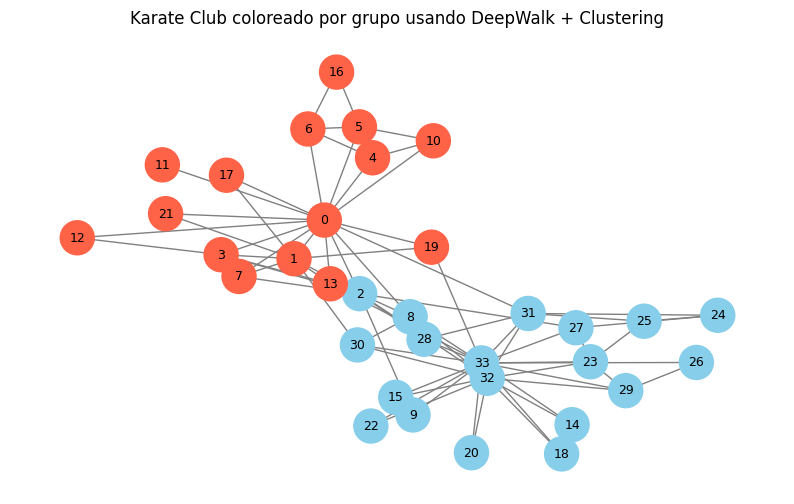

In [31]:
club_labels = community_labels
node_colors = [
    "tomato" if club_labels[n] == 1 else "skyblue"
    for n in G.nodes()
]
plt.figure(figsize=(10, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Karate Club coloreado por grupo usando DeepWalk + Clustering")
plt.axis("off")
plt.show()

### 5.3 Separar en comunidades entrenando NN a partir de los embeddings
#### Objetivo: ¿Podemos entrenar un modelo que, viendo la red y unos pocos nodos etiquetados, aprenda a predecir el grupo de los demás?”



#### 5.3.1 Crear train/test masks
Esto es una demo, no haremos división sofisticada.
Etiquetaremos unos pocos nodos para entrenamiento y dejar el resto para test.

Por ejemplo, 4 nodos de entrenamiento por clase.

* simulamos un caso semi-supervisado
* solo conocemos la etiqueta de unos pocos nodos
* queremos inferir la de los demás usando red + propagación de información

In [32]:
# Hay que asegurarse de que haya representación de ambos grupos.
club_labels = nx.get_node_attributes(G, "club")
mrhi_nodes = [n for n in G.nodes() if club_labels[n] == "Mr. Hi"]
officer_nodes = [n for n in G.nodes() if club_labels[n] == "Officer"]

mrhi_nodes, officer_nodes

([0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21],
 [9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])

In [33]:
# Elegimos unos pocos:
train_nodes = mrhi_nodes[:4] + officer_nodes[:4]
train_nodes

[0, 1, 2, 3, 9, 14, 15, 18]

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Los embeddings son las características de entrada; solo train_nodes aporta etiquetas.
features = torch.tensor(node_embeddings, dtype=torch.float32)
label_map = {"Mr. Hi": 0, "Officer": 1}
labels = torch.tensor(
    [label_map[club_labels[node]] for node in nodes],
    dtype=torch.long
)
train_indices = torch.tensor([nodes.index(node) for node in train_nodes])
test_indices = torch.tensor(
    [index for index, node in enumerate(nodes) if node not in train_nodes]
 )

class EmbeddingClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, embeddings):
        return self.layers(embeddings)

torch.manual_seed(42)
embedding_classifier = EmbeddingClassifier(features.shape[1])
optimizer = torch.optim.Adam(embedding_classifier.parameters(), lr=0.01, weight_decay=1e-4)

for epoch in range(500):
    embedding_classifier.train()
    optimizer.zero_grad()
    logits = embedding_classifier(features)
    loss = F.cross_entropy(logits[train_indices], labels[train_indices])
    loss.backward()
    optimizer.step()

embedding_classifier.eval()
with torch.no_grad():
    probabilities = torch.softmax(embedding_classifier(features), dim=1)
    predictions = probabilities.argmax(dim=1)

df_nodes["nn_community"] = predictions.numpy()
df_nodes["nn_confidence"] = probabilities.max(dim=1).values.numpy()
df_nodes["nn_predicted_label"] = df_nodes["nn_community"].map({0: "Mr. Hi", 1: "Officer"})

df_nodes.loc[
    ~df_nodes["node"].isin(train_nodes),
    ["node", "nn_predicted_label", "nn_confidence"],
]

,node,nn_predicted_label,nn_confidence
4,4,Mr. Hi,0.999958
5,5,Mr. Hi,0.999974
6,6,Mr. Hi,0.999981
7,7,Mr. Hi,0.999521
8,8,Officer,0.850916
10,10,Mr. Hi,0.999993
11,11,Mr. Hi,0.999945
12,12,Mr. Hi,0.999979
13,13,Mr. Hi,0.963737
16,16,Mr. Hi,0.999958


In [35]:
df_nodes["nn_correct"] = df_nodes["nn_predicted_label"] == df_nodes["club"]
accuracy = df_nodes.loc[~df_nodes["node"].isin(train_nodes), "nn_correct"].mean()
print(f"Accuracy on test nodes: {accuracy:.2%}")    

Accuracy on test nodes: 96.15%


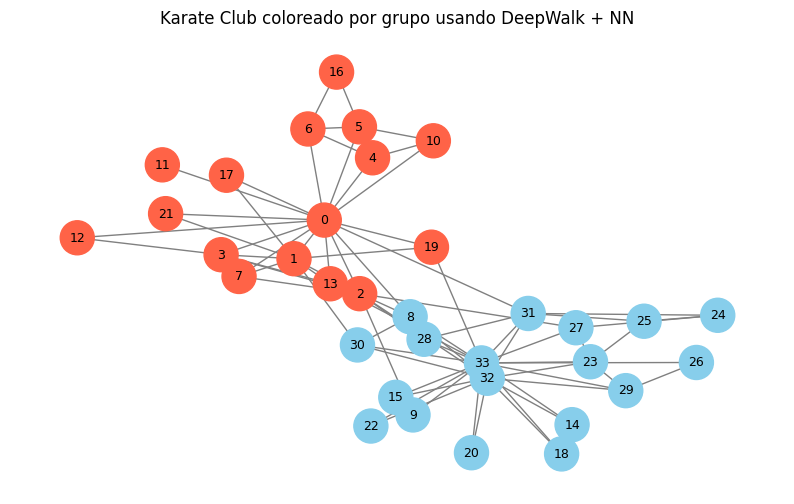

In [36]:
club_labels = df_nodes["nn_predicted_label"]
node_colors = [
    "tomato" if club_labels[n] == "Mr. Hi" else "skyblue"
    for n in G.nodes()
]
plt.figure(figsize=(10, 6))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Karate Club coloreado por grupo usando DeepWalk + NN")
plt.axis("off")
plt.show()

## 6. GNN

### Objetivo:
¿Podemos entrenar un modelo que, viendo la red y unos pocos nodos etiquetados, aprenda a predecir el grupo de los demás?”

### 6.1 Preparar los datos para una GNN

In [37]:
!pip install torch torchvision torchaudio
!pip install torch-geometric

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ------------ --------------------------- 1.3/4.1 MB 6.1 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.1 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 6.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 1.0/122.1 MB 5.0 MB/s eta 0:00:25
    --------------------------------------- 2.6/122.1 MB 6.0 MB/s eta 0:00:20
   - -------------------------------------- 3.9/122.1 MB 6.5 MB/s eta 0:00:19
   - -------------------------------------- 5.8/122.1 MB 6.9 MB/s eta 0:00:17
   -- ------------------------------------- 7.1/122.1 MB 6.8 MB/s eta 0:00:17
   -- ------------------------------------- 8.7/122.1 MB 6.9 MB/s eta 0:00:17
   --- ------------------------------------ 10.2/122.1 MB 7.0 MB/s eta 0:00:16
   --- 

  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------------------------------- -------- 1.0/1.3 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 4.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import torch
import torch_geometric
import torch.nn.functional as F
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv
data = from_networkx(G)
data

C:\Users\m_fon\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data(edge_index=[2, 156], club=[34], weight=[156], name='Zachary's Karate Club', num_nodes=34)

### Crear las etiquetas

Convertimos:
* Mr. Hi → 0
* Officer → 1

In [39]:
club_labels = nx.get_node_attributes(G, "club")
label_map = {"Mr. Hi": 0, "Officer": 1}
y = torch.tensor([label_map[club_labels[n]] for n in G.nodes()], dtype=torch.long)
y

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

### Crear _features_ iniciales

In [40]:
# usamos la matriz de identidad como características iniciales (one-hot encoding de los nodos)
num_nodes = G.number_of_nodes()
x = torch.eye(num_nodes, dtype=torch.float)
x.shape


torch.Size([34, 34])

In [41]:
# Guardamos las características y etiquetas en el objeto Data
data.x = x
data.y = y
data

Data(edge_index=[2, 156], club=[34], weight=[156], name='Zachary's Karate Club', num_nodes=34, x=[34, 34], y=[34])

### 6.2 Crear train/test masks
Como es una demo, no hace falta hacerlo sofisticado.
Podemos etiquetar unos pocos nodos para entrenamiento y dejar el resto para test.

Por ejemplo, 4 nodos de entrenamiento por clase.

* simulamos un caso semi-supervisado
* solo conocemos la etiqueta de unos pocos nodos
* queremos inferir la de los demás usando red + propagación de información

In [42]:
# DEPENDE de los train_nodes definidos anteriormente (5.3.1)
# Creamos máscaras:
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.ones(num_nodes, dtype=torch.bool)

train_mask[train_nodes] = True
test_mask[train_nodes] = False
print("Train mask:", train_mask)
print("Test mask:", test_mask)
data.train_mask = train_mask
data.test_mask = test_mask

Train mask: tensor([ True,  True,  True,  True, False, False, False, False, False,  True,
        False, False, False, False,  True,  True, False, False,  True, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False])
Test mask: tensor([False, False, False, False,  True,  True,  True,  True,  True, False,
         True,  True,  True,  True, False, False,  True,  True, False,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True])


In [43]:
# Comprobamos que las máscaras se han creado correctamente:
print("Nodos de entrenamiento:", data.train_mask.sum().item())
print("Nodos de test:", data.test_mask.sum().item())

Nodos de entrenamiento: 8
Nodos de test: 26


### 6.3. Definir una GCN mínima
Modelo muy pequeño: 2 capas.

In [44]:
# cada nodo mezcla información con sus vecinos, luego vuelve a mezclar, 
# y al final obtiene una salida útil para clasificarlo.

# primera capa para generación de los embeddings y la segunda

class SimpleGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

Los tres parámetros de *_ init _* significan:

* in_channels: dimensión de entrada de cada nodo (en nuestro caso 34)
* hidden_channels: tamaño de la representación intermedia (capa oculta)
* out_channels: dimensión de salida final (2 clases)



In [45]:
# Instanciamos el modelo:
model = SimpleGCN(
    in_channels=data.x.shape[1],
    hidden_channels=16,
    out_channels=2
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

### 6.4 Entrenar el modelo

In [46]:
# Función de entrenamiento:
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

In [47]:
# Función de evaluación:
@torch.no_grad()
def evaluate(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = (pred[mask] == data.y[mask]).sum().item()
    total = mask.sum().item()
    acc = correct / total
    return acc, pred

In [48]:
# Entrenamos el modelo durante varias épocas y evaluamos su rendimiento en cada una.
losses = []
train_accs = []
test_accs = []

for epoch in range(1, 201):
    loss = train()
    train_acc, _ = evaluate(data.train_mask)
    test_acc, pred = evaluate(data.test_mask)

    losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

Epoch 020 | Loss: 0.2591 | Train Acc: 1.000 | Test Acc: 0.885
Epoch 040 | Loss: 0.0662 | Train Acc: 1.000 | Test Acc: 0.923
Epoch 060 | Loss: 0.0245 | Train Acc: 1.000 | Test Acc: 0.923
Epoch 080 | Loss: 0.0145 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 100 | Loss: 0.0109 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 120 | Loss: 0.0092 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 140 | Loss: 0.0082 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 160 | Loss: 0.0075 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 180 | Loss: 0.0069 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 200 | Loss: 0.0065 | Train Acc: 1.000 | Test Acc: 0.846


### 6.5. Visualizar evolución del entrenamiento

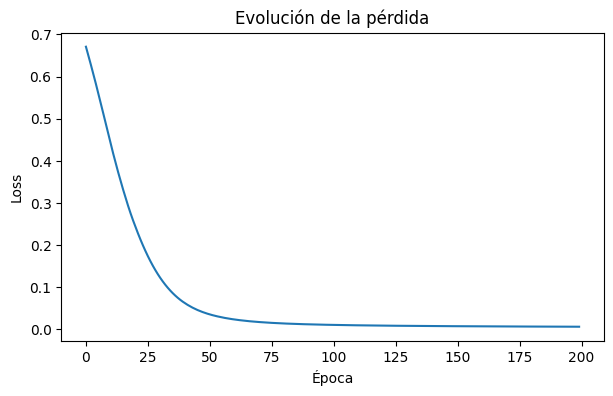

In [123]:
# Pérdida a lo largo del entrenamiento
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

la función de pérdida va bajando conforme avanza el entrenamiento, siendo 75 un buen momento de epochs

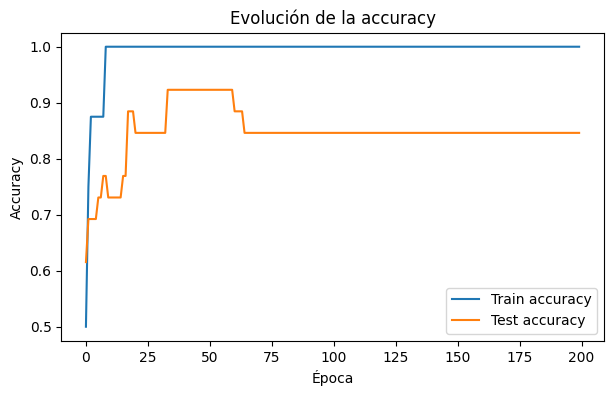

In [49]:
# Accuracy a lo largo del entrenamiento
plt.figure(figsize=(7, 4))
plt.plot(train_accs, label="Train accuracy")
plt.plot(test_accs, label="Test accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

respecto al accuracy, rápidamente el etrenamiento llega bien y en el test se estabiliza más tarde. 

### 6.6. Ver predicciones finales por nodo

In [50]:
_, final_pred = evaluate(torch.ones(num_nodes, dtype=torch.bool))

inv_label_map = {0: "Mr. Hi", 1: "Officer"}

df_results = pd.DataFrame({
    "node": list(G.nodes()),
    "true_label": [club_labels[n] for n in G.nodes()],
    "pred_label": [inv_label_map[int(final_pred[n])] for n in G.nodes()],
    "train_node": [bool(data.train_mask[n]) for n in G.nodes()]
})

df_results["correct"] = df_results["true_label"] == df_results["pred_label"]
df_results.head(10)

,node,true_label,pred_label,train_node,correct
0,0,Mr. Hi,Mr. Hi,True,True
1,1,Mr. Hi,Mr. Hi,True,True
2,2,Mr. Hi,Mr. Hi,True,True
3,3,Mr. Hi,Mr. Hi,True,True
4,4,Mr. Hi,Mr. Hi,False,True
5,5,Mr. Hi,Mr. Hi,False,True
6,6,Mr. Hi,Mr. Hi,False,True
7,7,Mr. Hi,Mr. Hi,False,True
8,8,Mr. Hi,Officer,False,False
9,9,Officer,Officer,True,True


In [51]:
_, final_pred = evaluate(torch.ones(num_nodes, dtype=torch.bool))

inv_label_map = {0: "Mr. Hi", 1: "Officer"}

df_results = pd.DataFrame({
    "node": list(G.nodes()),
    "true_label": [club_labels[n] for n in G.nodes()],
    "pred_label": [inv_label_map[int(final_pred[n])] for n in G.nodes()],
    "train_node": [bool(data.train_mask[n]) for n in G.nodes()]
})

df_results["correct"] = df_results["true_label"] == df_results["pred_label"]
df_results.head(10)

,node,true_label,pred_label,train_node,correct
0,0,Mr. Hi,Mr. Hi,True,True
1,1,Mr. Hi,Mr. Hi,True,True
2,2,Mr. Hi,Mr. Hi,True,True
3,3,Mr. Hi,Mr. Hi,True,True
4,4,Mr. Hi,Mr. Hi,False,True
5,5,Mr. Hi,Mr. Hi,False,True
6,6,Mr. Hi,Mr. Hi,False,True
7,7,Mr. Hi,Mr. Hi,False,True
8,8,Mr. Hi,Officer,False,False
9,9,Officer,Officer,True,True


In [52]:
# Y resumen:
df_results["correct"].mean()

np.float64(0.8823529411764706)

In [53]:
# Si miramos solo los nodos de test:
test_correct = df_results.loc[~df_results["train_node"], "correct"].mean()
print("Accuracy en test:", test_correct)

Accuracy en test: 0.8461538461538461


aquí el método de embedding funciona mejor que una red neuronal profunda, el problema es que tiene pocos casos de entrenamiento, por éso funciona mejor. Pero cuanto mayor sea el conjunto de nodos del entreamiento mejor funciona la profundidad

### 6.7. Visualizar red con predicciones
#### Color por predicción
* rojo = Mr. Hi
* azul = Officer
#### Resaltar los nodos usados para entrenar
* borde negro grueso

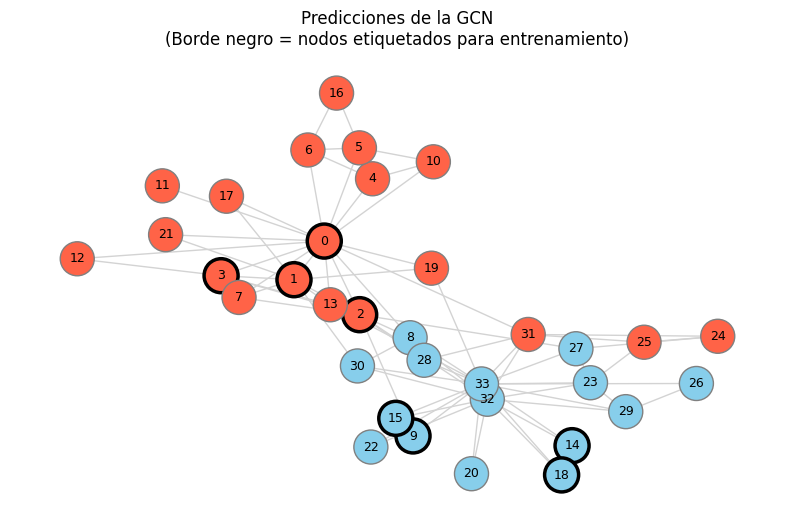

In [ ]:
# en negro los nodos usados para entrenar
# probablmrnte esos nodos están alejados de los vecinos seleccionados
pred_colors = [
    "tomato" if inv_label_map[int(final_pred[n])] == "Mr. Hi" else "skyblue"
    for n in G.nodes()
]

edgecolors = ["black" if data.train_mask[n] else "gray" for n in G.nodes()]
linewidths = [2.5 if data.train_mask[n] else 1.0 for n in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw_networkx_edges(G, pos=pos, edge_color="lightgray")
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_color=pred_colors,
    node_size=600,
    edgecolors=edgecolors,
    linewidths=linewidths
)
nx.draw_networkx_labels(G, pos=pos, font_size=9)

plt.title("Predicciones de la GCN\n(Borde negro = nodos etiquetados para entrenamiento)")
plt.axis("off")
plt.show()

#### ¿Qué hemos hecho?
* hemos dado etiquetas reales solo a unos pocos nodos
* el modelo ha inferido el resto
* la estructura de la red ha sido clave para propagar señal

### 6.8. Visualizar aciertos y errores
* verde = predicción correcta
* rojo = error

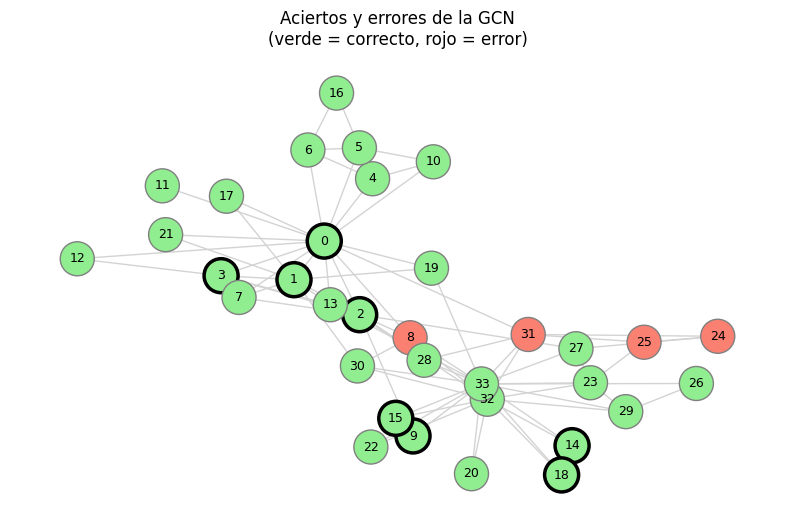

In [55]:
correct_colors = [
    "lightgreen" if df_results.loc[df_results["node"] == n, "correct"].values[0] else "salmon"
    for n in G.nodes()
]

plt.figure(figsize=(10, 6))
nx.draw_networkx_edges(G, pos=pos, edge_color="lightgray")
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_color=correct_colors,
    node_size=600,
    edgecolors=edgecolors,
    linewidths=linewidths
)
nx.draw_networkx_labels(G, pos=pos, font_size=9)

plt.title("Aciertos y errores de la GCN\n(verde = correcto, rojo = error)")
plt.axis("off")
plt.show()

## 7. Visualización de embeddings
Vamos a modificar un poco el modelo para extraer la **capa oculta**.

In [56]:
# mismo modelo que antes, pero devuelve capa oculta si return_embeddings=True
class SimpleGCNWithEmb(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index, return_embeddings=False):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        out = self.conv2(h, edge_index)
        if return_embeddings:
            return out, h
        return out

In [57]:
# entrenamos el nuevo modelo
model = SimpleGCNWithEmb(
    in_channels=data.x.shape[1],
    hidden_channels=16,
    out_channels=2
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
losses = []
train_accs = []
test_accs = []

for epoch in range(1, 201):
    loss = train()
    train_acc, _ = evaluate(data.train_mask)
    test_acc, pred = evaluate(data.test_mask)

    losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

Epoch 020 | Loss: 0.3237 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 040 | Loss: 0.0643 | Train Acc: 1.000 | Test Acc: 0.885
Epoch 060 | Loss: 0.0227 | Train Acc: 1.000 | Test Acc: 0.885
Epoch 080 | Loss: 0.0135 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 100 | Loss: 0.0102 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 120 | Loss: 0.0086 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 140 | Loss: 0.0076 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 160 | Loss: 0.0070 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 180 | Loss: 0.0065 | Train Acc: 1.000 | Test Acc: 0.846
Epoch 200 | Loss: 0.0061 | Train Acc: 1.000 | Test Acc: 0.846


In [58]:
# Extraer salida final y embeddings
model.eval()
out, h = model(data.x, data.edge_index, return_embeddings=True)

print("Shape de out:", out.shape)
print("Shape de h:", h.shape)


Shape de out: torch.Size([34, 2])
Shape de h: torch.Size([34, 16])


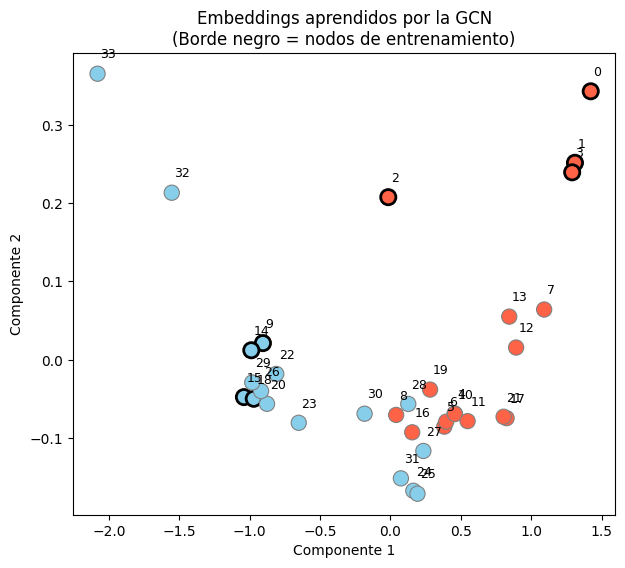

In [ ]:
from sklearn.decomposition import PCA

# Convertir embeddings a numpy
embeddings = h.detach().cpu().numpy()

# Reducir a 2 dimensiones
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

# Colores por clase real
true_colors = [
    "tomato" if club_labels[n] == "Mr. Hi" else "skyblue"
    for n in G.nodes()
]

# Bordes para nodos de entrenamiento
train_nodes_set = set(train_nodes)
marker_edges = ["black" if n in train_nodes_set else "gray" for n in G.nodes()]
line_widths = [2.0 if n in train_nodes_set else 0.8 for n in G.nodes()]

# Visualización
plt.figure(figsize=(7, 6))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=true_colors,
    s=120,
    edgecolors=marker_edges,
    linewidths=line_widths
)

for i, node in enumerate(G.nodes()):
    plt.text(emb_2d[i, 0] + 0.02, emb_2d[i, 1] + 0.02, str(node), fontsize=9)

plt.title("Embeddings aprendidos por la GCN\n(Borde negro = nodos de entrenamiento)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

# en negro los nodos usados en el set de entrenamiento
# los vectores del grupo rojo están más disperso. los ocho nodos del etnreanmiento ha sido para los vectores y entrenamientos  
# la generación de vectores es muy fluida. la creación de los vectores depende de esa tarea.

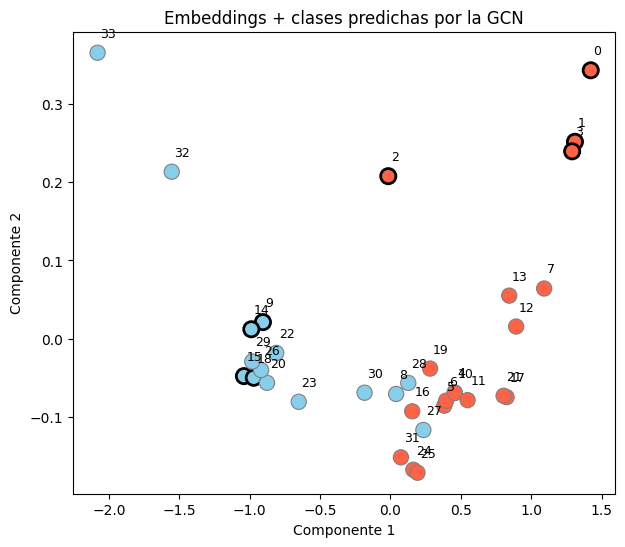

In [60]:
# visualizando por etiqueta prevista
pred = out.argmax(dim=1)

pred_colors = [
    "tomato" if int(pred[n]) == 0 else "skyblue"
    for n in G.nodes()
]

plt.figure(figsize=(7, 6))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=pred_colors,
    s=120,
    edgecolors=marker_edges,
    linewidths=line_widths
)

for i, node in enumerate(G.nodes()):
    plt.text(emb_2d[i, 0] + 0.02, emb_2d[i, 1] + 0.02, str(node), fontsize=9)

plt.title("Embeddings + clases predichas por la GCN")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

Vamos a visualizar los embeddings generados por GNN.
En el gráfico de la izquierda vamos a pintar según clase real,
en el de la derecha según predicción del algoritmo

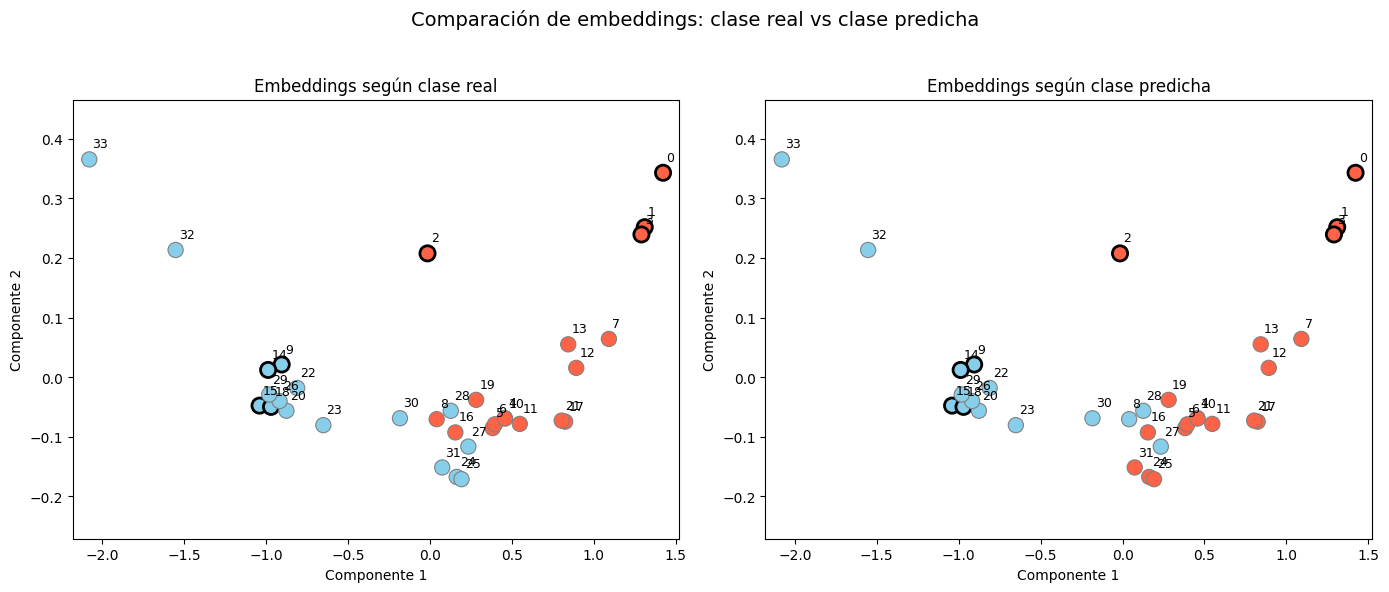

In [61]:
# Predicciones del modelo
pred = out.argmax(dim=1)

# Colores por clase real
true_colors = [
    "tomato" if club_labels[n] == "Mr. Hi" else "skyblue"
    for n in G.nodes()
]

# Colores por clase predicha
pred_colors = [
    "tomato" if int(pred[n]) == 0 else "skyblue"
    for n in G.nodes()
]

# Bordes para resaltar nodos de entrenamiento
train_nodes_set = set(train_nodes)
marker_edges = ["black" if n in train_nodes_set else "gray" for n in G.nodes()]
line_widths = [2.0 if n in train_nodes_set else 0.8 for n in G.nodes()]

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ----- Gráfico 1: embeddings según clase real -----
axes[0].scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=true_colors,
    s=120,
    edgecolors=marker_edges,
    linewidths=line_widths
)

for i, node in enumerate(G.nodes()):
    axes[0].text(
        emb_2d[i, 0] + 0.02,
        emb_2d[i, 1] + 0.02,
        str(node),
        fontsize=9
    )

axes[0].set_title("Embeddings según clase real")
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")

# ----- Gráfico 2: embeddings según clase predicha -----
axes[1].scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=pred_colors,
    s=120,
    edgecolors=marker_edges,
    linewidths=line_widths
)

for i, node in enumerate(G.nodes()):
    axes[1].text(
        emb_2d[i, 0] + 0.02,
        emb_2d[i, 1] + 0.02,
        str(node),
        fontsize=9
    )

axes[1].set_title("Embeddings según clase predicha")
axes[1].set_xlabel("Componente 1")
axes[1].set_ylabel("Componente 2")
xmin, xmax = emb_2d[:, 0].min() - 0.1, emb_2d[:, 0].max() + 0.1
ymin, ymax = emb_2d[:, 1].min() - 0.1, emb_2d[:, 1].max() + 0.1

axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(ymin, ymax)

axes[1].set_xlim(xmin, xmax)
axes[1].set_ylim(ymin, ymax)
fig.suptitle("Comparación de embeddings: clase real vs clase predicha", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Igual que el anterior, pero vamos a marcar los embeddings correspondientes a los nodos mal clasificados.
Solo imprime etiqueta en nodos relevantes: entrenamiento, errores o algo grado

Nodos destacados: [0, 1, 2, 3, 8, 9, 14, 15, 18, 24, 25, 31, 32, 33]


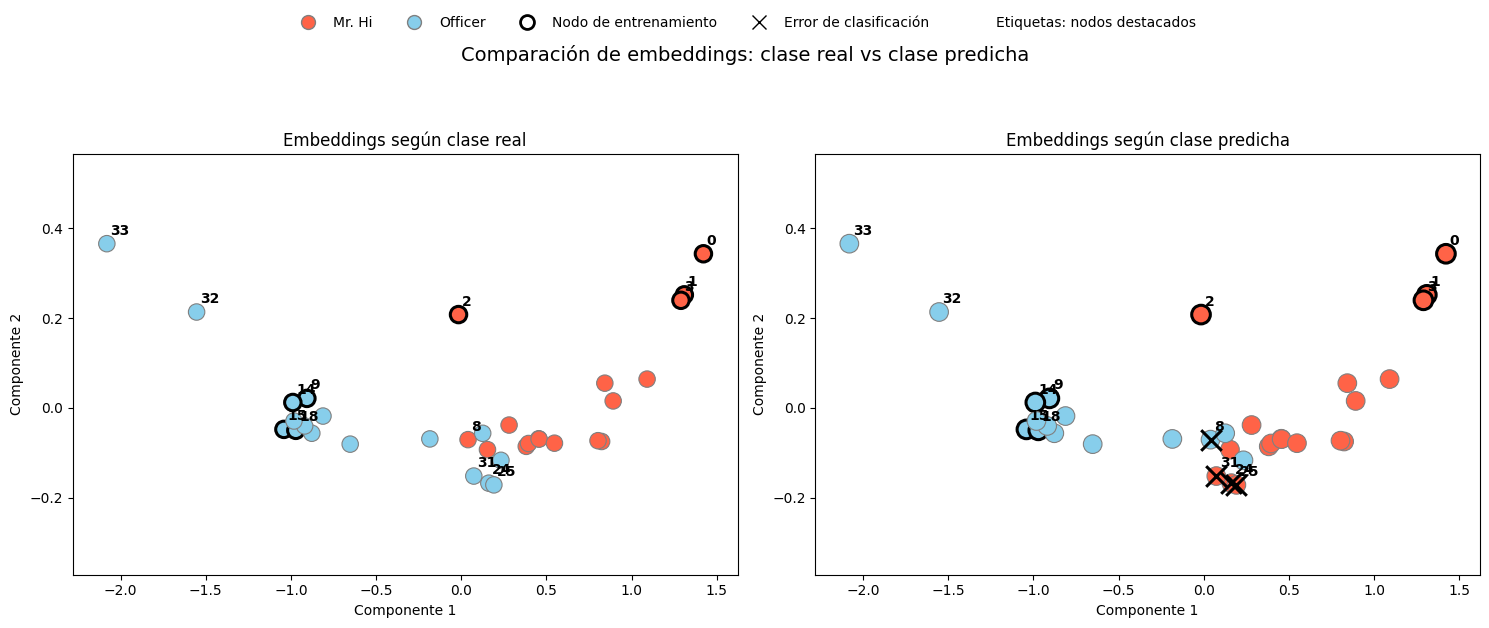

In [62]:
from matplotlib.lines import Line2D

# Predicciones del modelo
pred = out.argmax(dim=1)

# Colores por clase real
true_colors = [
    "tomato" if club_labels[n] == "Mr. Hi" else "skyblue"
    for n in G.nodes()
]

# Colores por clase predicha
pred_colors = [
    "tomato" if int(pred[n]) == 0 else "skyblue"
    for n in G.nodes()
]

# Bordes para nodos de entrenamiento
train_nodes_set = set(train_nodes)
marker_edges = ["black" if n in train_nodes_set else "gray" for n in G.nodes()]
line_widths = [2.2 if n in train_nodes_set else 0.8 for n in G.nodes()]

# Nodos mal clasificados
wrong_nodes = [
    n for n in G.nodes()
    if club_labels[n] != ("Mr. Hi" if int(pred[n]) == 0 else "Officer")
]

# Algunos nodos centrales (por grado)
top_degree_nodes = sorted(degrees, key=degrees.get, reverse=True)[:3]

# Nodos a destacar: entrenamiento + errores + algunos centrales
highlight_nodes = sorted(set(train_nodes) | set(wrong_nodes) | set(top_degree_nodes))

print("Nodos destacados:", highlight_nodes)

# Límites comunes
xmin, xmax = emb_2d[:, 0].min() - 0.2, emb_2d[:, 0].max() + 0.2
ymin, ymax = emb_2d[:, 1].min() - 0.2, emb_2d[:, 1].max() + 0.2

# Mapa nodo -> índice en emb_2d
node_list = list(G.nodes())
node_to_idx = {node: i for i, node in enumerate(node_list)}

# Crear figura
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# =========================
# Izquierda: clase real
# =========================
axes[0].scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=true_colors,
    s=140,
    edgecolors=marker_edges,
    linewidths=line_widths
)

for node in highlight_nodes:
    i = node_to_idx[node]
    axes[0].text(
        emb_2d[i, 0] + 0.02,
        emb_2d[i, 1] + 0.02,
        str(node),
        fontsize=10,
        fontweight="bold"
    )

axes[0].set_title("Embeddings según clase real")
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")
axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(ymin, ymax)

# =========================
# Derecha: clase predicha
# =========================
axes[1].scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=pred_colors,
    s=180,
    edgecolors=marker_edges,
    linewidths=line_widths
)

for node in highlight_nodes:
    i = node_to_idx[node]
    axes[1].text(
        emb_2d[i, 0] + 0.02,
        emb_2d[i, 1] + 0.02,
        str(node),
        fontsize=10,
        fontweight="bold"
    )

# Marcar errores con X
for n in wrong_nodes:
    i = node_to_idx[n]
    axes[1].scatter(
        emb_2d[i, 0],
        emb_2d[i, 1],
        marker='x',
        s=220,
        c='black',
        linewidths=2.2
    )

axes[1].set_title("Embeddings según clase predicha")
axes[1].set_xlabel("Componente 1")
axes[1].set_ylabel("Componente 2")
axes[1].set_xlim(xmin, xmax)
axes[1].set_ylim(ymin, ymax)

# Leyenda común
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Mr. Hi',
           markerfacecolor='tomato', markeredgecolor='gray', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Officer',
           markerfacecolor='skyblue', markeredgecolor='gray', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Nodo de entrenamiento',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=2, markersize=10),
    Line2D([0], [0], marker='x', color='black', label='Error de clasificación',
           markersize=10, linewidth=0),
    Line2D([0], [0], marker=None, color='none', label='Etiquetas: nodos destacados')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05)
)

fig.suptitle("Comparación de embeddings: clase real vs clase predicha", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 8. Varias capas ocultas
### 8.1 Generando modelos

In [63]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import time

class FlexibleGCNWithEmb(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_hidden_layers, dropout=0.0):
        super().__init__()

        if num_hidden_layers < 1:
            raise ValueError("num_hidden_layers debe ser >= 1")

        self.dropout = dropout
        self.convs = torch.nn.ModuleList()

        # Primera capa: entrada -> oculta
        self.convs.append(GCNConv(in_channels, hidden_channels))

        # Capas ocultas adicionales: oculta -> oculta
        for _ in range(num_hidden_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        # Capa de salida
        self.out_conv = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index, return_embeddings=False):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            if self.dropout > 0:# El dropout se utiliza para evitar el sobreajuste durante el entrenamiento, pero se desactiva durante la evaluación.
                x = F.dropout(x, p=self.dropout, training=self.training)

        h = x
        out = self.out_conv(h, edge_index)

        if return_embeddings:
            return out, h
        return out

In [64]:
# Funciones de entrenamiento y evaluación
# Estas funciones te sirven para cualquier número de capas.
@torch.no_grad()
def evaluate_model(model, data, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = (pred[mask] == data.y[mask]).sum().item()
    total = mask.sum().item()
    acc = correct / total
    return acc, pred

@torch.no_grad()
def measure_inference_time(model, data, repeats=200):
    model.eval()

    # pequeña ejecución previa
    _ = model(data.x, data.edge_index)

    start = time.perf_counter()
    for _ in range(repeats):
        out = model(data.x, data.edge_index)
    end = time.perf_counter()

    total_time = end - start
    mean_time = total_time / repeats

    return {
        "total_inference_time": total_time,
        "mean_inference_time": mean_time
    }

def train_model(model, data, optimizer, epochs=200, verbose=False):
    losses = []
    train_accs = []
    test_accs = []
    epoch_times = []
    
    total_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()

        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

        loss.backward()
        optimizer.step()

        epoch_end = time.perf_counter()
        epoch_time = epoch_end - epoch_start
        epoch_times.append(epoch_time)

        train_acc, _ = evaluate_model(model, data, data.train_mask)
        test_acc, pred = evaluate_model(model, data, data.test_mask)

        losses.append(loss.item())
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if verbose and epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f} | Epoch Time: {epoch_time:.6f}s")

    total_end = time.perf_counter()
    total_training_time = total_end - total_start

    return {
        "losses": losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "epoch_times": epoch_times,
        "total_training_time": total_training_time,
        "mean_epoch_time": sum(epoch_times) / len(epoch_times),
        "final_pred": pred,
    }

In [65]:
# Función para ejecutar un experimento completo
def run_experiment(data, num_hidden_layers, hidden_channels=16, lr=0.01, weight_decay=5e-4,
                   epochs=200, dropout=0.0, seed=42, verbose=False):
    torch.manual_seed(seed)

    model = FlexibleGCNWithEmb(
        in_channels=data.x.shape[1],
        hidden_channels=hidden_channels,
        out_channels=len(torch.unique(data.y)),
        num_hidden_layers=num_hidden_layers,
        dropout=dropout
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = train_model(model, data, optimizer, epochs=epochs, verbose=verbose)

    test_acc, pred = evaluate_model(model, data, data.test_mask)
    global_acc, _ = evaluate_model(model, data, torch.ones(data.num_nodes, dtype=torch.bool))

    inference_stats = measure_inference_time(model, data, repeats=500)

    return {
        "model": model,
        "history": history,
        "test_acc": test_acc,
        "global_acc": global_acc,
        "pred": pred,
        "total_training_time": history["total_training_time"],
        "mean_epoch_time": history["mean_epoch_time"],
        "total_inference_time": inference_stats["total_inference_time"],
        "mean_inference_time": inference_stats["mean_inference_time"]
    }

In [66]:
# Comparar 1, 2 y 3 capas ocultas
layers = [1, 5, 10, 20, 40]
results = {}

for n_layers in layers:
    print(f"\nEntrenando modelo con {n_layers} capa(s) oculta(s)...")
    results[n_layers] = run_experiment(
        data=data,
        num_hidden_layers=n_layers,
        hidden_channels=16,
        lr=0.01,
        weight_decay=5e-4,
        epochs=200,
        dropout=0.0,
        seed=42,
        verbose=False
    )

    print(f"Test accuracy ({n_layers} capas): {results[n_layers]['test_acc']:.3f}")
    print(f"Accuracy global ({n_layers} capas): {results[n_layers]['global_acc']:.3f}")
    print(f"Training time total ({n_layers} capas): {results[n_layers]['total_training_time']:.4f}s")
    print(f"Tiempo medio por época ({n_layers} capas): {results[n_layers]['mean_epoch_time']:.6f}s")
    print(f"Tiempo medio de inferencia ({n_layers} capas): {results[n_layers]['mean_inference_time']:.8f}s")


Entrenando modelo con 1 capa(s) oculta(s)...
Test accuracy (1 capas): 0.846
Accuracy global (1 capas): 0.882
Training time total (1 capas): 0.7022s
Tiempo medio por época (1 capas): 0.001758s
Tiempo medio de inferencia (1 capas): 0.00065487s

Entrenando modelo con 5 capa(s) oculta(s)...
Test accuracy (5 capas): 0.962
Accuracy global (5 capas): 0.971
Training time total (5 capas): 1.7655s
Tiempo medio por época (5 capas): 0.004186s
Tiempo medio de inferencia (5 capas): 0.00201484s

Entrenando modelo con 10 capa(s) oculta(s)...
Test accuracy (10 capas): 1.000
Accuracy global (10 capas): 1.000
Training time total (10 capas): 3.0315s
Tiempo medio por época (10 capas): 0.007146s
Tiempo medio de inferencia (10 capas): 0.00363419s

Entrenando modelo con 20 capa(s) oculta(s)...
Test accuracy (20 capas): 0.577
Accuracy global (20 capas): 0.676
Training time total (20 capas): 5.9501s
Tiempo medio por época (20 capas): 0.013981s
Tiempo medio de inferencia (20 capas): 0.00811340s

Entrenando mode

### 8.2 Comparando resultados

In [67]:
import pandas as pd
summary = pd.DataFrame({
    "num_hidden_layers": list(results.keys()),
    "test_acc": [results[n]["test_acc"] for n in results],
    #"global_acc": [results[n]["global_acc"] for n in results],
    "train_time_total_s": [results[n]["total_training_time"] for n in results],
    #"train_time_per_epoch_s": [results[n]["mean_epoch_time"] for n in results],
    "inference_time_mean_s": [results[n]["mean_inference_time"] for n in results]
})

summary

,num_hidden_layers,test_acc,train_time_total_s,inference_time_mean_s
0,1,0.846154,0.702195,0.000655
1,5,0.961538,1.765520,0.002015
2,10,1.000000,3.031514,0.003634
3,20,0.576923,5.950108,0.008113
4,40,0.461538,11.156611,0.014316


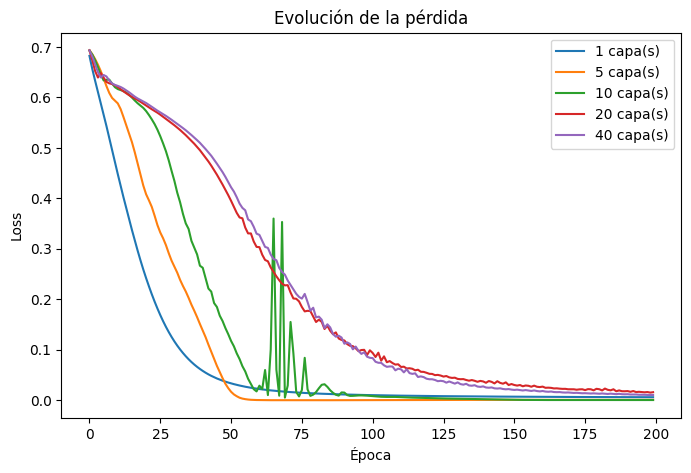

In [68]:
plt.figure(figsize=(8, 5))

for n_layers in results:
    plt.plot(results[n_layers]["history"]["losses"], label=f"{n_layers} capa(s)")

plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

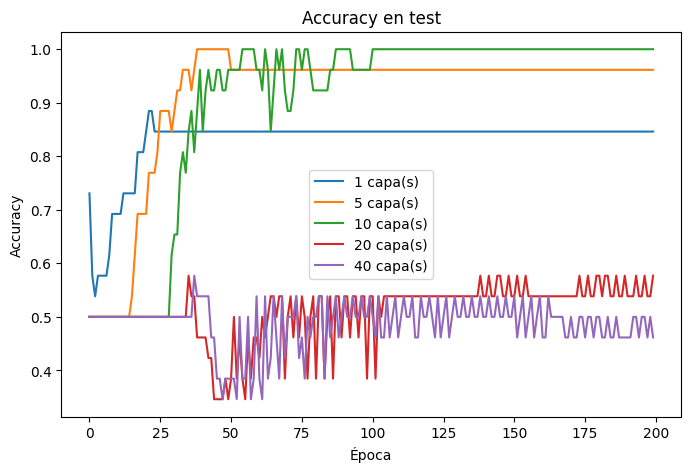

In [69]:
plt.figure(figsize=(8, 5))

for n_layers in results:
    plt.plot(results[n_layers]["history"]["test_accs"], label=f"{n_layers} capa(s)")

plt.title("Accuracy en test")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

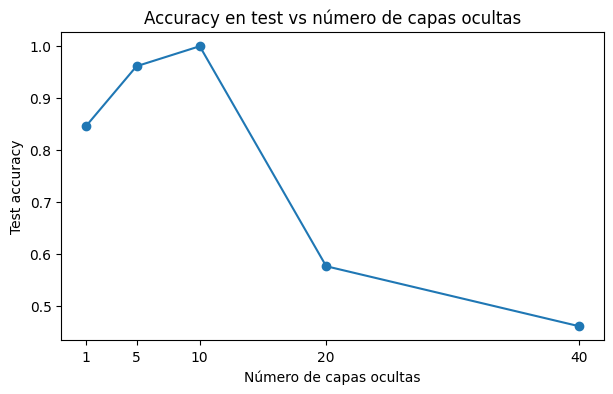

In [70]:
# Gráfico de accuracy y tiempo
# A - Accuracy por número de capas
plt.figure(figsize=(7, 4))
plt.plot(summary["num_hidden_layers"], summary["test_acc"], marker="o")
plt.title("Accuracy en test vs número de capas ocultas")
plt.xlabel("Número de capas ocultas")
plt.ylabel("Test accuracy")
plt.xticks(summary["num_hidden_layers"])
plt.show()

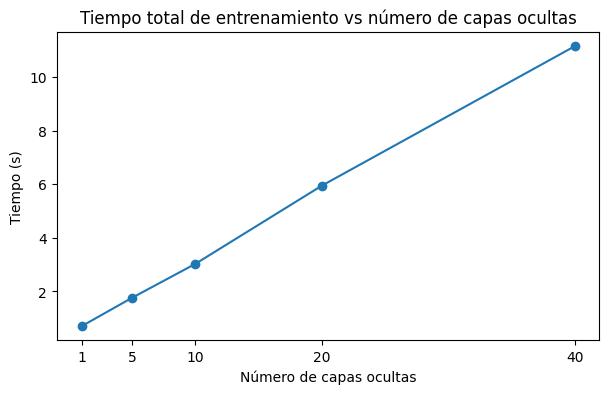

In [71]:
# B - Tiempo total de entrenamiento por número de capas
plt.figure(figsize=(7, 4))
plt.plot(summary["num_hidden_layers"], summary["train_time_total_s"], marker="o")
plt.title("Tiempo total de entrenamiento vs número de capas ocultas")
plt.xlabel("Número de capas ocultas")
plt.ylabel("Tiempo (s)")
plt.xticks(summary["num_hidden_layers"])
plt.show()

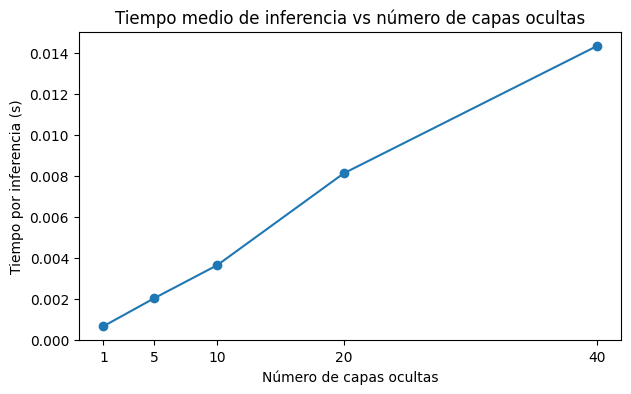

In [72]:
# C - Tiempo medio de inferencia por número de capas
plt.figure(figsize=(7, 4))
plt.plot(summary["num_hidden_layers"], summary["inference_time_mean_s"], marker="o")
plt.title("Tiempo medio de inferencia vs número de capas ocultas")
plt.xlabel("Número de capas ocultas")
plt.ylabel("Tiempo por inferencia (s)")
plt.xticks(summary["num_hidden_layers"])
plt.show()

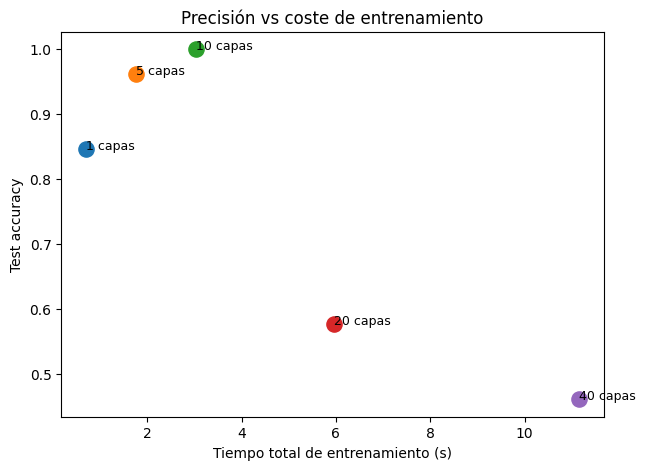

In [73]:
# Scatter: tiempo vs accuracy
plt.figure(figsize=(7, 5))

for _, row in summary.iterrows():
    plt.scatter(row["train_time_total_s"], row["test_acc"], s=120)
    plt.text(row["train_time_total_s"] + 0.001, row["test_acc"], f"{int(row['num_hidden_layers'])} capas", fontsize=9)

plt.title("Precisión vs coste de entrenamiento")
plt.xlabel("Tiempo total de entrenamiento (s)")
plt.ylabel("Test accuracy")
plt.show()

### 8.3 Análisis de Embeddings

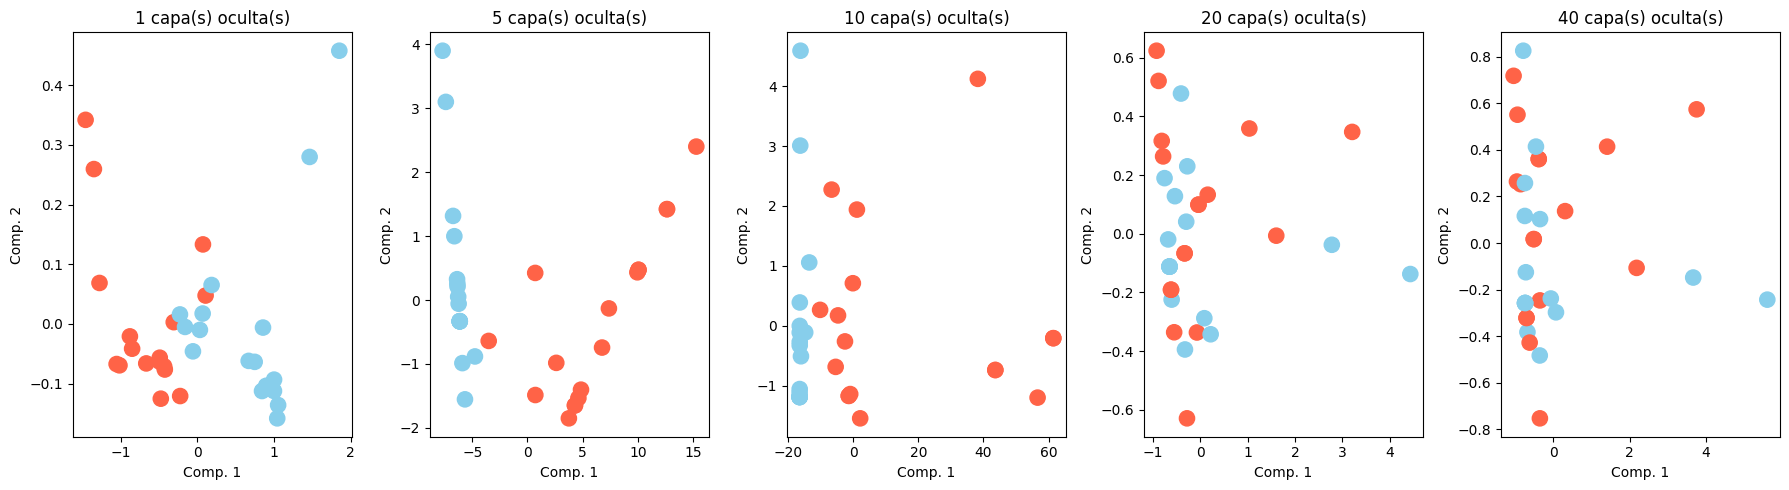

In [74]:
# comparar embeddings finales de cada modelo
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, len(layers), figsize=(18, 5))

for ax, n_layers in zip(axes, layers):
    model = results[n_layers]["model"]
    model.eval()
    out, h = model(data.x, data.edge_index, return_embeddings=True)

    emb = h.detach().cpu().numpy()
    emb_2d = PCA(n_components=2).fit_transform(emb)

    colors = [
        "tomato" if club_labels[n] == "Mr. Hi" else "skyblue"
        for n in G.nodes()
    ]

    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=120)

    ax.set_title(f"{n_layers} capa(s) oculta(s)")
    ax.set_xlabel("Comp. 1")
    ax.set_ylabel("Comp. 2")

plt.tight_layout()
plt.show()

* embedding_variance:
    * Mide cuánta dispersión tienen los embeddings.
    * Si baja mucho al aumentar capas, los nodos se parecen más entre sí.

* mean_cosine_similarity
    * Mide el parecido medio entre embeddings.
    * Si sube mucho, todos apuntan en direcciones más parecidas.
* silhouette
    * Mide separación entre grupos.
    * Si baja, las clases se separan peor.
* inter_intra_ratio
    * Compara separación entre clases con compactación dentro de clases.
    * Más alto suele ser mejor.

In [75]:
# Comparamos calidades de los embeddings para detectar oversmoothing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd

def mean_pairwise_distance(H, metric="euclidean"):
    D = pairwise_distances(H, metric=metric)
    n = D.shape[0]
    return D[np.triu_indices(n, k=1)].mean()

def mean_pairwise_cosine_similarity(H):
    S = cosine_similarity(H)
    n = S.shape[0]
    return S[np.triu_indices(n, k=1)].mean()

def embedding_variance(H):
    return np.var(H, axis=0).mean()

def intra_inter_class_distances(H, labels):
    D = pairwise_distances(H, metric="euclidean")
    intra, inter = [], []
    n = len(labels)
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                intra.append(D[i, j])
            else:
                inter.append(D[i, j])
    return np.mean(intra), np.mean(inter)

labels_np = np.array([label_map[club_labels[n]] for n in G.nodes()])

oversmoothing_rows = []

for n_layers in results:
    model = results[n_layers]["model"]
    model.eval()

    out, h = model(data.x, data.edge_index, return_embeddings=True)
    H = h.detach().cpu().numpy()

    var_emb = embedding_variance(H)
    cos_mean = mean_pairwise_cosine_similarity(H)
    dist_mean = mean_pairwise_distance(H)
    intra, inter = intra_inter_class_distances(H, labels_np)
    sil = silhouette_score(H, labels_np)

    oversmoothing_rows.append({
        "num_hidden_layers": n_layers,
        "test_acc": results[n_layers]["test_acc"],
        "embedding_variance": var_emb,
        "mean_cosine_similarity": cos_mean,
        "mean_pairwise_distance": dist_mean,
        "intra_class_dist": intra,
        "inter_class_dist": inter,
        "inter_intra_ratio": inter / intra,
        "silhouette": sil
    })

oversmooth_df = pd.DataFrame(oversmoothing_rows).sort_values("num_hidden_layers")
oversmooth_df.round(4)

,num_hidden_layers,test_acc,embedding_variance,mean_cosine_similarity,mean_pairwise_distance,intra_class_dist,inter_class_dist,inter_intra_ratio,silhouette
0,1,0.8462,0.0466,0.7505,1.0371,0.6845,1.368900,1.9999,0.4227
1,5,0.9615,3.3372,0.5276,8.4366,3.8322,12.770100,3.3323,0.6669
2,10,1.0000,38.2006,0.6597,24.2869,15.6144,32.449299,2.0782,0.4112
3,20,0.5769,0.0968,0.8423,1.2173,1.2300,1.205400,0.9800,-0.0155
4,40,0.4615,0.1523,0.8835,1.4988,1.5185,1.480400,0.9749,-0.0250


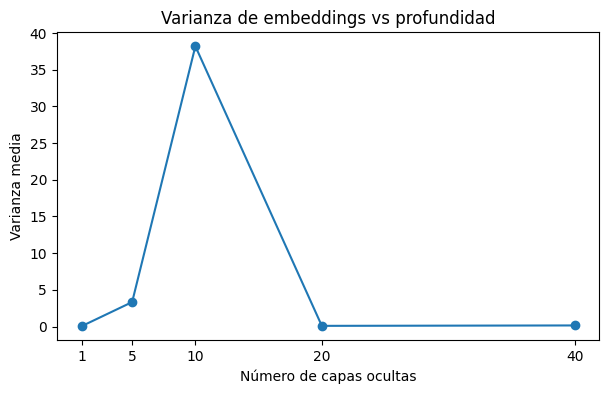

In [76]:
# graficos
# A - Variance of embeddings vs number of layers
plt.figure(figsize=(7, 4))
plt.plot(oversmooth_df["num_hidden_layers"], oversmooth_df["embedding_variance"], marker="o")
plt.title("Varianza de embeddings vs profundidad")
plt.xlabel("Número de capas ocultas")
plt.ylabel("Varianza media")
plt.xticks(oversmooth_df["num_hidden_layers"])
plt.show()

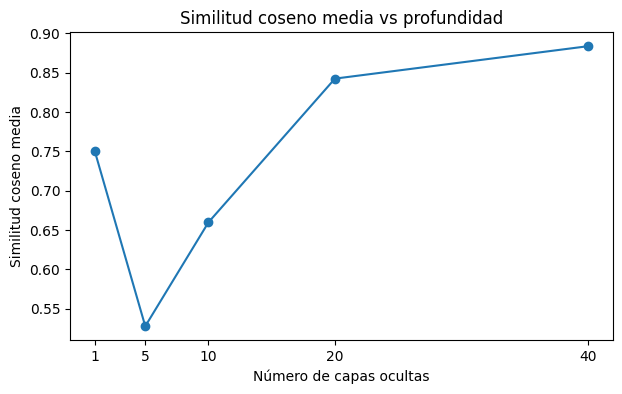

In [77]:
# Similitud coseno media vs profundidad
plt.figure(figsize=(7, 4))
plt.plot(oversmooth_df["num_hidden_layers"], oversmooth_df["mean_cosine_similarity"], marker="o")
plt.title("Similitud coseno media vs profundidad")
plt.xlabel("Número de capas ocultas")
plt.ylabel("Similitud coseno media")
plt.xticks(oversmooth_df["num_hidden_layers"])
plt.show()

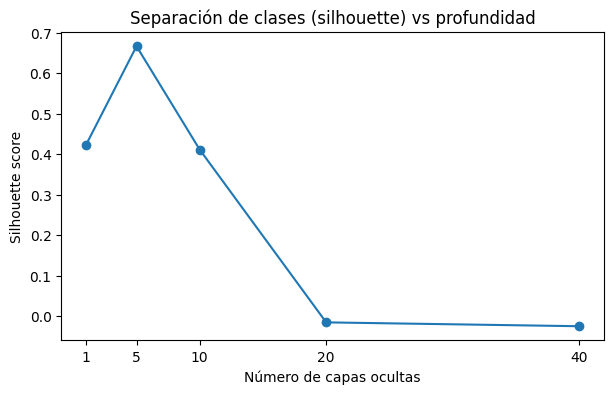

In [78]:
# Silhouette score vs profundidad
plt.figure(figsize=(7, 4))
plt.plot(oversmooth_df["num_hidden_layers"], oversmooth_df["silhouette"], marker="o")
plt.title("Separación de clases (silhouette) vs profundidad")
plt.xlabel("Número de capas ocultas")
plt.ylabel("Silhouette score")
plt.xticks(oversmooth_df["num_hidden_layers"])
plt.show()